In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle

In [2]:
# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

csv_file = os.path.join(path,"Reviews.csv")
df = pd.read_csv(csv_file)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.shape

(568454, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [6]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [7]:
df_clean = df[['Text','Score']]
df_clean.head(2)

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1


In [8]:
df_clean.isnull().sum()

,0
Text,0
Score,0


In [9]:
df['Text'][29]

"I don't know if it's the cactus or the tequila or just the unique combination of ingredients, but the flavour of this hot sauce makes it one of a kind!  We picked up a bottle once on a trip we were on and brought it back home with us and were totally blown away!  When we realized that we simply couldn't find it anywhere in our city we were bummed.<br /><br />Now, because of the magic of the internet, we have a case of the sauce and are ecstatic because of it.<br /><br />If you love hot sauce..I mean really love hot sauce, but don't want a sauce that tastelessly burns your throat, grab a bottle of Tequila Picante Gourmet de Inclan.  Just realize that once you taste it, you will never want to use any other sauce.<br /><br />Thank you for the personal, incredible service!"

In [10]:
#Rating dist
score_counts = df_clean['Score'].value_counts().sort_index()
for score, count in score_counts.items():
  perc = (count/len(df_clean))*100
  print(f"{score} stars : {perc:.2f}%")

#biased more data -> good reviews

1 stars : 9.19%
2 stars : 5.24%
3 stars : 7.50%
4 stars : 14.19%
5 stars : 63.88%


In [11]:
df_clean['Score'].value_counts()

,count
Score,
5,363122
4,80655
1,52268
3,42640
2,29769


In [12]:
for score in [1,2,3,4,5]:
  sample_rev = df_clean[df_clean['Score'] == score]['Text'].iloc[0]
  print(f"\n🌟 {score}-STAR REVIEW:")
  print(f"{sample_rev}")


🌟 1-STAR REVIEW:
Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

🌟 2-STAR REVIEW:
If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.

🌟 3-STAR REVIEW:
This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.

🌟 4-STAR REVIEW:
This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recomme

In [13]:
#remove all 3 star - confusion

# deep copy and shallow copy

In [14]:
df_binary = df_clean[df_clean['Score'] !=3].copy()
df_binary['sentiment'] = (df_binary['Score']>=4).astype(int)

In [15]:
df_binary.head(2)

,Text,Score,sentiment
0,I have bought several of the Vitality canned d...,5,1
1,Product arrived labeled as Jumbo Salted Peanut...,1,0


In [16]:
df_binary['Score'].value_counts()

,count
Score,
5,363122
4,80655
1,52268
2,29769


In [17]:
#binary classification setup

In [18]:
print(f"ORIGINAL DATA: {len(df_clean):,} reviews")
#after removing 3 star reviews
print(f"AFTER 3-STAR REMOVAL : {len(df_binary):,} reviews")
#class dis
print(f"Negative (1-2) star : {sum(df_binary['sentiment']==0):,}")
print(f"Positive (4-5) star : {sum(df_binary['sentiment']==1):,}")

ORIGINAL DATA: 568,454 reviews
AFTER 3-STAR REMOVAL : 525,814 reviews
Negative (1-2) star : 82,037
Positive (4-5) star : 443,777


In [19]:
#handle class imbalnce
from sklearn.utils import resample

negative_reviews = df_binary[df_binary['sentiment']==0]
positive_reviews = df_binary[df_binary['sentiment']==1]

n_minority = len(negative_reviews)

positive_downsampled = resample(positive_reviews,
                                replace=False,
                                n_samples=n_minority)

In [20]:
df_balanced = pd.concat([negative_reviews, positive_downsampled])
df_balanced.head(10)

,Text,Score,sentiment
1,Product arrived labeled as Jumbo Salted Peanut...,1,0
3,If you are looking for the secret ingredient i...,2,0
12,My cats have been happily eating Felidae Plati...,1,0
16,I love eating them and they are good for watch...,2,0
26,"The candy is just red , No flavor . Just plan...",1,0
50,"This oatmeal is not good. Its mushy, soft, I d...",1,0
62,Arrived in 6 days and were so stale i could no...,1,0
67,"I purchased the Mango flavor, and to me it doe...",2,0
73,Buyer Beware Please! This sweetener is not for...,1,0
74,It is okay. I would not go out of my way to b...,2,0


In [21]:
df_balanced = df_balanced.sample(frac=1).reset_index(drop=True)

In [22]:
df_balanced.head(10)

,Text,Score,sentiment
0,Love the salad dressing and the Spagetti sauce...,2,0
1,My Brazilian Raintree is thriving in my living...,5,1
2,I would like to give this a better review but ...,1,0
3,My daughter is 6 months old. This was one of t...,5,1
4,After trying about 30 different brands of Gree...,5,1
5,The Summer Berry has an overwhelming flavor of...,1,0
6,My younger son actually bought this for himsel...,5,1
7,I have 3 cats with 3 different personalities. ...,2,0
8,This product maybe good but I can not testify ...,1,0
9,"VERY good, arrived fast. Of all the kettle sty...",5,1


In [23]:
#after balancing
print(f"Negative : {sum(df_balanced['sentiment']==0):,}")
print(f"Positive : {sum(df_balanced['sentiment']==1):,}")

Negative : 82,037
Positive : 82,037


In [24]:
#much smaller sample
sample_size = 50000
df_sample = df_balanced.sample(n=sample_size)
sample_neg = sum(df_sample['sentiment']==0)
sample_pos = sum(df_sample['sentiment']==1)

In [25]:
print(f"-ve : {sample_neg:,}")
print(f"+ve : {sample_pos:,}")

-ve : 24,943
+ve : 25,057


In [26]:
import re

In [27]:
df_sample['Text'].iloc[3]

'I love this cereal i eat it every morning adding maple syrup makes even more satisfying'

In [28]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'<[^>]+>',' ',text)
  text = re.sub(r'^a-zA-Z\s','',text)
  text = " ".join(text.split())
  return text

In [29]:
df_sample['clean_text'] = df_sample['Text'].apply(clean_text)

In [30]:
df_sample.head(2)

,Text,Score,sentiment,clean_text
159671,The best after meal digestives EVER!<br /><br ...,5,1,the best after meal digestives ever! i can't k...
83561,With the rush of `flavored water' drinks on th...,2,0,with the rush of `flavored water' drinks on th...


In [31]:
df_sample['clean_text'].iloc[3]

'i love this cereal i eat it every morning adding maple syrup makes even more satisfying'

In [32]:
df_sample['Text'].iloc[3]

'I love this cereal i eat it every morning adding maple syrup makes even more satisfying'

In [33]:
MAX_FEATURES = 10000 # vocabulary
MAX_LEN = 100 # lngth   compute cost

In [34]:
X = df_sample['clean_text'].values #feature
y = df_sample['sentiment'].values  #target

In [35]:
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token = '<OOV>')
tokenizer.fit_on_texts(X)

In [36]:
#convert sent in to sequences
X_sequences = tokenizer.texts_to_sequences(X)

In [37]:
print(X_sequences[0],end=',')
print('\n')
print(X_sequences[1],end=',')

[2, 114, 84, 459, 1, 181, 3, 167, 262, 27, 11, 14, 390, 141, 3, 3864, 23, 29, 38, 2, 80, 5169],

[19, 2, 3421, 8, 361, 1, 660, 23, 2, 539, 3, 392, 6, 147, 892, 1642, 5, 99, 3, 49, 1438, 6, 5, 1241, 8, 1, 17, 160, 7, 126, 28, 68, 35, 76, 22, 5, 198, 8, 29, 1010, 2, 9934, 2, 1625, 16, 5, 391, 467, 497, 13, 514, 24, 3896, 1882, 4, 42, 5, 2871, 1318, 24, 3111, 2135, 492, 3, 160, 26, 271, 26, 35, 3, 1655, 51, 5, 194, 767, 8, 116, 1469, 2, 1161, 357, 5, 1642, 8, 2, 399, 7, 42, 2, 497, 8, 3896, 1882, 17, 16, 6616, 139, 42, 2, 138, 1318, 26, 271, 26, 35, 109, 3, 204, 7, 76, 16, 5, 2871, 1786, 30, 17, 85, 5, 3161, 30, 13, 16, 182, 1026, 288, 3, 144, 92, 214, 3, 357, 211, 3376, 730, 7, 43, 1704, 2, 44, 7, 122, 460, 2, 461, 44, 2, 352, 44, 42, 7132, 2160, 4653, 83, 2, 806, 44, 11, 910, 1, 2, 489, 439, 1722, 238, 106, 21, 257, 18, 1110, 32, 8, 259, 205, 17, 6, 5418, 7328, 1, 11, 2, 1749, 2117, 37, 7, 53, 6, 30, 24, 9, 3, 67, 465, 37, 14, 3462, 22, 1878],

In [38]:
X_padded = pad_sequences(X_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

In [39]:
print(X_padded[0],end=',')
print('\n')
print(X_padded[1],end=',')

[   2  114   84  459    1  181    3  167  262   27   11   14  390  141
    3 3864   23   29   38    2   80 5169    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0],

[  19    2 3421    8  361    1  660   23    2  539    3  392    6  147
  892 1642    5   99    3   49 1438    6    5 1241    8    1   17  160
    7  126   28   68   35   76   22    5  198    8   29 1010    2 9934
    2 1625   16    5  391  467  497   13  514   24 3896 1882    4   42
    5 2871 1318   24 3111 2135  492    3  160   26  271   26   35    3
 1655   51    5  194  767    8  116 1469    2 1161  357    5 1642    8
    2  399    7   42    2  497    8 3896 1882   17   16 6616  1

In [40]:
X_train, X_test, y_train , y_test = train_test_split(
    X_padded, y,
    test_size=0.20,
    stratify=y
)

In [41]:
## RNN model - NN

In [42]:
def create_rnn_model():
  model = Sequential([
      Embedding(input_dim=MAX_FEATURES, output_dim=128, input_length=MAX_LEN),
      SimpleRNN(units=64, return_sequences=False),
      Dropout(0.50),
      Dense(32, activation='relu'),
      Dense(1, activation='sigmoid')
  ])
  return model

In [43]:
rnn_model = create_rnn_model()

#compile the nn
rnn_model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [44]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=5, #30? # epochs lesser -> 234,5 -> 150.   ->
    validation_split=0.20,
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5123 - loss: 0.6953 - val_accuracy: 0.5255 - val_loss: 0.6895
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5466 - loss: 0.6826 - val_accuracy: 0.5253 - val_loss: 0.6841
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6058 - loss: 0.6372 - val_accuracy: 0.5260 - val_loss: 0.6952
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6152 - loss: 0.5846 - val_accuracy: 0.5360 - val_loss: 0.7501
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6559 - loss: 0.5214 - val_accuracy: 0.5401 - val_loss: 0.8551


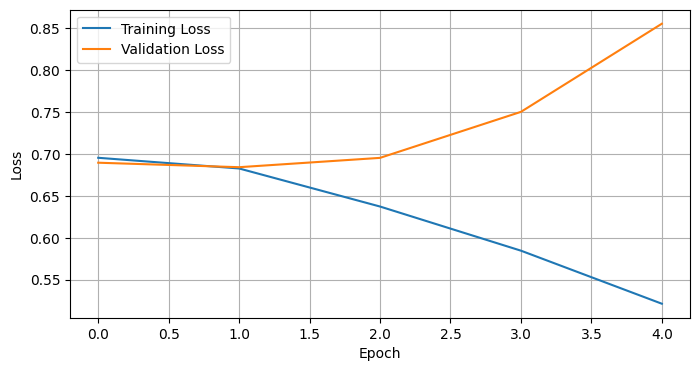

In [45]:
plt.figure(figsize=(8,4))
plt.plot(rnn_history.history['loss'],label='Training Loss')
plt.plot(rnn_history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

In [46]:
#LSTM Model

In [48]:
def create_lstm_model():
  model = Sequential([
      Embedding(input_dim=MAX_FEATURES, output_dim=128, input_length=MAX_LEN),
      LSTM(units=64, return_sequences=False),
      Dropout(0.50),
      Dense(32, activation='relu'),
      Dense(1, activation='sigmoid')
  ])
  return model

lstm_model = create_lstm_model()

#compile the nn
lstm_model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [49]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=5, #30? # epochs lesser -> 234,5 -> 150.   ->
    validation_split=0.20,
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5332 - loss: 0.6858 - val_accuracy: 0.5726 - val_loss: 0.6623
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6562 - loss: 0.6043 - val_accuracy: 0.7350 - val_loss: 0.5493
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7393 - loss: 0.5512 - val_accuracy: 0.5561 - val_loss: 0.6750
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7229 - loss: 0.5507 - val_accuracy: 0.7380 - val_loss: 0.5765
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8624 - loss: 0.3631 - val_accuracy: 0.8648 - val_loss: 0.3420


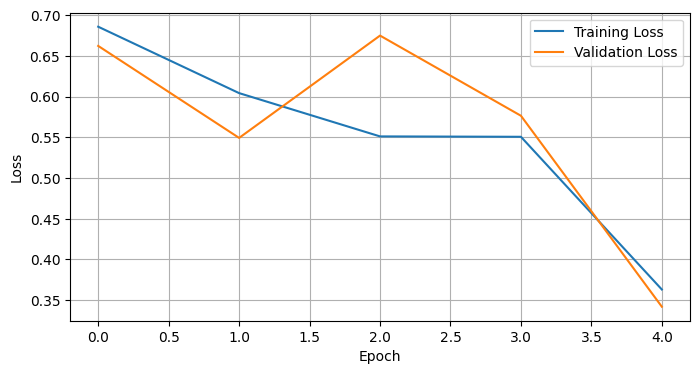

In [50]:
plt.figure(figsize=(8,4))
plt.plot(lstm_history.history['loss'],label='Training Loss')
plt.plot(lstm_history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

In [51]:
#next step -> increase epoch, tune parameter, callbacks - early , model check ,

In [52]:
param_grid = {
    'model_type':['rnn','lstm'],
    "embedding_dim":[32,16,64,128],
    "units":[16,32,64,128,256],
    "dropout_rate":[0.3,0.1,0.5],
    "learning_rate":[0.0001, 0.001, 0.01]
}

#bo time -> exact

In [53]:
def create_model_with_params(model_type='lstm',embedding_dim=128,
                             units=64,dropout_rate=0.5, learning_rate=0.001):
  model = Sequential([
      Embedding(MAX_FEATURES, embedding_dim, input_length=MAX_LEN)
  ])

  if model_type == 'lstm':
    model.add(LSTM(units, return_sequences=False))
  else:
    model.add(SimpleRNN(units,return_sequences=False))

  model.add(Dropout(dropout_rate))
  model.add(Dense(32,activation='relu'))
  model.add(Dense(1,activation='sigmoid'))

  model.compile(
      optimizer=Adam(learning_rate=learning_rate),
      loss='binary_crossentropy',
      metrics = ['accuracy']
  )
  return model

In [54]:
def random_search(n_trials=8):
  results=[]
  np.random.seed(10)
  for i in range(n_trials):
    params = {
        'model_type':str(np.random.choice(param_grid['model_type'])),
        'embedding_dim': int(np.random.choice(param_grid['embedding_dim'])),
        'units': int(np.random.choice(param_grid['units'])),
        'dropout_rate': float(np.random.choice(param_grid['dropout_rate'])),
        'learning_rate': float(np.random.choice(param_grid['learning_rate'])),
    }
    print(f"\n--- Trial {i+1}/{n_trials} ---")

    try:
      model = create_model_with_params(**params)
      history = model.fit(
          X_train, y_train,
          batch_size=128,
          epochs=3,
          validation_split=0.2
      )

      val_accuracy = max(history.history['val_accuracy'])

      results.append({
          'trial':i+1,
          'params':params,
          'val_accuracy' : val_accuracy,
          'model':model
      })

      print(f"Validation Accuracy : {val_accuracy:.2f}")
    except Exception as e:
      print(f"Error : {str(e)}")
  return results

In [55]:
search_results = random_search(8)


--- Trial 1/8 ---
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5277 - loss: 0.6913 - val_accuracy: 0.5416 - val_loss: 0.6899
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5495 - loss: 0.6884 - val_accuracy: 0.5584 - val_loss: 0.6849
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5556 - loss: 0.6770 - val_accuracy: 0.5692 - val_loss: 0.6671
Validation Accuracy : 0.57

--- Trial 2/8 ---
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5214 - loss: 0.6927 - val_accuracy: 0.5265 - val_loss: 0.6916
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6398 - loss: 0.6309 - val_accuracy: 0.8106 - val_loss: 0.4947
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8424 - loss: 0.4316 - val_accuracy: 0.8493 - val_loss: 0.3996
Validation Accuracy : 0.85

--- Trial 3/8 ---
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5922 - loss: 0.6577 - val_accuracy: 0.8080 - val_loss: 0

In [56]:
best_result = max(search_results, key=lambda x: x['val_accuracy'])
best_result

{'trial': 8,
 'params': {'model_type': 'lstm',
  'embedding_dim': 16,
  'units': 128,
  'dropout_rate': 0.1,
  'learning_rate': 0.01},
 'val_accuracy': 0.8836249709129333,
 'model': <Sequential name=sequential_9, built=True>}

In [57]:
if search_results:
  best_params = best_result['params']

  best_model = create_model_with_params(**best_params)

  callbacks = [
      ModelCheckpoint(
          'best_amazon_sentiment_model.h5',
          monitor = 'val_accuracy',
          save_best_only=True,
          mode='max',
      ),

      EarlyStopping(
          monitor='val_loss',
          patience=3,
          restore_best_weights=True
      )
  ]

  print("Final model training.....\n")
  final_history = best_model.fit(
      X_train, y_train,
      batch_size=128,
      epochs=10,
      validation_split = 0.20,
      callbacks=callbacks,
  )

  with open('amazon_sentiment_tokenizer.pkl',"wb") as f:
    pickle.dump(tokenizer, f)

else:
  print(f"Cannot train model - issues")

Final model training.....

Epoch 1/10
244/250 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5171 - loss: 0.6938

250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5257 - loss: 0.6924 - val_accuracy: 0.5359 - val_loss: 0.6881
Epoch 2/10
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5678 - loss: 0.6687

250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6132 - loss: 0.6392 - val_accuracy: 0.7165 - val_loss: 0.6199
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8112 - loss: 0.4635

250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8333 - loss: 0.4107 - val_accuracy: 0.8604 - val_loss: 0.3317
Epoch 4/10
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9014 - loss: 0.2549

250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9032 - loss: 0.2526 - val_accuracy: 0.8805 - val_loss: 0.3025
Epoch 5/10
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9320 - loss: 0.1836

250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9302 - loss: 0.1884 - val_accuracy: 0.8839 - val_loss: 0.3091
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9507 - loss: 0.1434 - val_accuracy: 0.8825 - val_loss: 0.3497
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9635 - loss: 0.1125 - val_accuracy: 0.8795 - val_loss: 0.3488


In [58]:
#model training -> best hype

loaded_model = load_model('best_amazon_sentiment_model.h5')
with open('amazon_sentiment_tokenizer.pkl','rb') as f:
  loaded_tokenizer = pickle.load(f)

print("Model loaded successfully!!!")

Model loaded successfully!!!


In [59]:
y_pred_prob = loaded_model.predict(X_test)
y_pred = (y_pred_prob > 0.50).astype(int).flatten()

test_accuracy = accuracy_score(y_test, y_pred)
print(f"test_accuracy : {test_accuracy:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
test_accuracy : 0.88


In [60]:
test_sentences = ['this product is really good, i am a big fan of this',
                  "terrible quality, waste of my money",
                  "great food, amazing quality can do better but for now i am happy"]

def predict_sentiment(text):
  clean = clean_text(text)
  sequence = loaded_tokenizer.texts_to_sequences([clean])
  padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post')
  prob = loaded_model.predict(padded)[0][0]
  sentiment = "Positive" if prob >0.50 else "Negative"
  return sentiment, prob

In [61]:
predict_sentiment(test_sentences[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


('Positive', np.float32(0.99306434))